In [3]:
import cv2
import numpy as np 

dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)

marker_image = np.zeros((200,200), dtype=np.uint8)

marker_image = cv2.aruco.generateImageMarker(dictionary, 0, 200, marker_image, 1)

cv2.imwrite("end_effector_marker_0.png", marker_image)
print("Marker generated! Print this at a known size")

Marker generated! Print this at a known size


### Live Camera

In [ ]:
import cv2
import numpy as np 

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_AUTOFOCUS, 0)

dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)

camera_matrix = np.array([[1000.0, 0.0, 960.0],
                          [0.0, 1000.0, 540.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)

dist_coeffs = np.zeros((4,1), dtype=np.float32)

marker_length = 0.05 # Length of marker in meters

marker_corners_3d = np.array([
    [-marker_length/2, marker_length/2, 0],
    [marker_length/2, marker_length/2, 0],
    [-marker_length/2, -marker_length/2, 0],
    [marker_length/2, -marker_length/2, 0]
], dtype=np.float32)

print("Starting tracking loop. Press `q` to quit.")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    corners, ids, rejected = detector.detectMarkers(frame)
    if ids is not None: 
        cv2.aruco.drawDetectedMarkers(frame, corners, ids)

        for i in range(len(ids)):

            success_pnp, rvec, tvec = cv2.solvePnP(
                marker_corners_3d, corners[i], camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_IPPE_SQUARE
            )

            if success_pnp:
                cv2.drawFrameAxes(frame, camera_matrix, dist_coeffs, rvec, tvec)

                x, y, z = tvec.flatten()

                text = f"X: {x*100:.2f}cm Y: {y*100:.2f}cm Z: {z*100:.2f}cm"
                cv2.putText(frame, text, (10,30), 
                            cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.7,
                            color=(0, 255, 0), thickness=2)
            
    cv2.imshow("Overhead End Effector Tracking", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


### Image - Not Working

In [1]:
import cv2
import numpy as np 

image_path = r"/home/kshitij_jha/prap-25-26/vision/marker copy.jpeg"

frame = cv2.imread(image_path)
if frame is None:
    print(f"Error: Could not load image at {image_path}")
    exit()


dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)

camera_matrix = np.array([[2480.0, 0.0, 600.0],
                          [0.0, 2480.0, 800.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)

dist_coeffs = np.zeros((4,1), dtype=np.float32)

marker_length = 0.05 # Length of marker in meters

marker_corners_3d = np.array([
    [-marker_length/2, marker_length/2, 0],
    [marker_length/2, marker_length/2, 0],
    [-marker_length/2, -marker_length/2, 0],
    [marker_length/2, -marker_length/2, 0]
], dtype=np.float32)

corners, ids, _ = detector.detectMarkers(frame)
print(corners, ids)

if ids is not None:
    for i in range(len(ids)):

        success, rvec, tvec = cv2.solvePnP(
            marker_corners_3d, corners[i], camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_IPPE_SQUARE
        )

        if success:

            cv2.aruco.drawDetectedMarkers(frame, corners, ids)
            cv2.drawFrameAxes(frame, camera_matrix, dist_coeffs, rvec, tvec, 0.03)

            x, y, z = tvec.flatten()
            print(f"ID: {ids[i][0]} | Pos: X: {x*100:.2f}cm Y: {y*100:.2f}cm Z: {z*100:.2f}cm")

            text = f"X: {x*100:.2f}cm Y: {y*100:.2f}cm Z: {z*100:.2f}cm"
            cv2.putText(frame, text, (20,50), cv2.FONT_HERSHEY_SIMPLEX,
                        fontScale=1, color=(0, 255, 0), thickness=2)
            
    cv2.imshow("Marker Detection", frame)
    cv2.waitKey(0)

else:
    print("No ArUco marker found in this image")

cv2.destroyAllWindows()

(array([[[ 464.,  934.],
        [ 553.,  918.],
        [ 568., 1008.],
        [ 479., 1024.]]], dtype=float32),) [[0]]
ID: 0 | Pos: X: -2.32cm Y: 4.73cm Z: 68.53cm


QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

### Image - Inputting Pixels (to be used: Updated later)

In [6]:
import cv2 
import numpy as np 

marker_length = 0.05
camera_matrix = np.array([[2480.0, 0.0, 600.0],
                          [0.0, 2480.0, 800.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)
dist_coeffs = np.zeros((4,1), dtype=np.float32)

def get_pixel_to_metric_ratio(corners):
    """Calculates meters represented by one pixel at current value of Z"""

    pixel_perimeter = cv2.arcLength(corners[0], True)
    avg_pixel_side = pixel_perimeter / 4.0

    return marker_length / avg_pixel_side

def transform_to_world_frame(target_px, marker_center_px, m_per_px):
    """Converts pixel value to metric units"""

    dx_px = target_px[0] - marker_center_px[0]
    dy_px = target_px[1] - marker_center_px[1]

    dx_m = dx_px * m_per_px
    dy_m = -(dy_px * m_per_px)

    return dx_m, dy_m

image = cv2.imread(r"/home/kshitij_jha/prap-25-26/vision/marker copy.jpeg")
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)

corners, ids, _ = detector.detectMarkers(image)

if ids is not None: 
    m_per_px = get_pixel_to_metric_ratio(corners)

    marker_center = np.mean(corners[0][0], axis=0)

    target_pixel = (333, 1175)

    rel_x, rel_y = transform_to_world_frame(target_pixel, marker_center, m_per_px)

    print(f"Object is {rel_x*100:.2f}cm X and {rel_y*100:.2f}cm Y from marker")
    print(f"Command to SO-101: Move X: {rel_x:.3f}, Y: {rel_y:.3f}")

Object is -10.07cm X and -11.23cm Y from marker
Command to SO-101: Move X: -0.101, Y: -0.112


### Image - Point Click (Only temporarily lights up)

In [3]:
import cv2
import numpy as np

CAMERA_MATRIX = np.array([[2480.0, 0.0, 600.0],
                          [0.0, 2480.0, 800.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)
DIST_COEFFS = np.zeros((4, 1))
MARKER_SIZE_METERS = 0.05

m_per_px = 0
marker_center_px = (0, 0)
display_frame = None
target_px = None

def on_mouse_click(event, u, v, flags, param):
    global target_px, m_per_px, marker_center_px
    if event == cv2.EVENT_LBUTTONDOWN:
        
        target_px = (u, v)

        dx_m = (u - marker_center_px[0]) * m_per_px
        dy_m = -(v - marker_center_px[1]) * m_per_px
        
        print(f"\n--- Target Selected ---")
        print(f"Pixel: ({u}, {v})")
        print(f"Relative to Marker: X: {dx_m:.4f}m, Y: {dy_m:.4f}m")
        print(f"In CM: X: {dx_m*100:.2f}cm, Y: {dy_m*100:.2f}cm")
        
        temp_img = display_frame.copy()
        cv2.circle(temp_img, (u, v), 5, (0, 0, 255), 1)
        text = f"X:{dx_m*100:.1f} Y:{dy_m*100:.1f} (cm)"
        cv2.putText(temp_img, text, (u + 10, v - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        cv2.imshow("SO-101 Coordinate Picker", temp_img)

def main():
    global m_per_px, marker_center_px, display_frame
    
    image = cv2.imread(r"/home/kshitij_jha/prap-25-26/vision/marker copy.jpeg")
    if image is None:
        print("Error: Could not find image.")
        return

    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(dictionary, parameters)
    
    corners, ids, _ = detector.detectMarkers(image)
    
    if ids is not None:
        
        pixel_perimeter = cv2.arcLength(corners[0], True)
        avg_pixel_side = pixel_perimeter / 4.0
        m_per_px = MARKER_SIZE_METERS / avg_pixel_side
        
        marker_center_px = np.mean(corners[0][0], axis=0)
        
        display_frame = image.copy()
        cv2.aruco.drawDetectedMarkers(display_frame, corners, ids)
        cv2.circle(display_frame, (int(marker_center_px[0]), int(marker_center_px[1])), 7, (255, 0, 0), -1)
        
        print("Marker Found. Click anywhere on the image to get distance.")
        
        cv2.namedWindow("SO-101 Coordinate Picker")
        cv2.setMouseCallback("SO-101 Coordinate Picker", on_mouse_click)
        
        while True:
            cv2.imshow("SO-101 Coordinate Picker", display_frame)
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == 27:
                break
    else:
        print("Error: No ArUco marker detected. Check lighting/focus.")

    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

Marker Found. Click anywhere on the image to get distance.

--- Target Selected ---
Pixel: (506, 658)
Relative to Marker: X: -0.0055m, Y: 0.1723m
In CM: X: -0.55cm, Y: 17.23cm

--- Target Selected ---
Pixel: (505, 659)
Relative to Marker: X: -0.0061m, Y: 0.1717m
In CM: X: -0.61cm, Y: 17.17cm


### Image - Point Click (Image lights up permanently)

In [1]:
import cv2
import numpy as np

CAMERA_MATRIX = np.array([[2480.0, 0.0, 600.0],
                          [0.0, 2480.0, 800.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)
DIST_COEFFS = np.zeros((4, 1))
MARKER_SIZE_METERS = 0.05 


m_per_px = 0
marker_center_px = (0, 0)
target_px = None 

def on_mouse_click(event, u, v, flags, param):
    global target_px, m_per_px, marker_center_px
    if event == cv2.EVENT_LBUTTONDOWN:
        target_px = (u, v)
        
        
        dx_m = (u - marker_center_px[0]) * m_per_px
        dy_m = -(v - marker_center_px[1]) * m_per_px
        
        print(f"\n[TARGET LOCKED]")
        print(f"Pixel: ({u}, {v})")
        print(f"Robot Meters -> X: {dx_m:.4f}, Y: {dy_m:.4f}")
        print(f"Robot CM     -> X: {dx_m*100:.2f}, Y: {dy_m*100:.2f}")

def main():
    global m_per_px, marker_center_px, target_px
    
    # Load your image
    image = cv2.imread(r"/home/kshitij_jha/prap-25-26/vision/marker copy.jpeg")
    if image is None:
        print("Error: Could not find image file.")
        return

    
    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(dictionary, parameters)
    
    corners, ids, _ = detector.detectMarkers(image)
    
    if ids is not None:
        
        pixel_perimeter = cv2.arcLength(corners[0], True)
        avg_pixel_side = pixel_perimeter / 4.0
        m_per_px = MARKER_SIZE_METERS / avg_pixel_side
        
        
        marker_center_px = np.mean(corners[0][0], axis=0)
        
        
        cv2.namedWindow("SO-101 Picker")
        cv2.setMouseCallback("SO-101 Picker", on_mouse_click)
        
        print("System Ready. Click an object to target it. Press 'q' to quit.")

        while True:
            
            draw_img = image.copy()
            
            
            cv2.aruco.drawDetectedMarkers(draw_img, corners, ids)
            
            
            cv2.circle(draw_img, (int(marker_center_px[0]), int(marker_center_px[1])), 8, (255, 0, 0), -1)

            
            if target_px is not None:
                u, v = target_px
                
                cv2.drawMarker(draw_img, (u, v), (0, 255, 255), cv2.MARKER_CROSS, 25, 2)
                cv2.circle(draw_img, (u, v), 12, (0, 255, 255), 1)
                
                
                dx_cm = (u - marker_center_px[0]) * m_per_px * 100
                dy_cm = -(v - marker_center_px[1]) * m_per_px * 100
                
                label = f"X:{dx_cm:.1f}cm Y:{dy_cm:.1f}cm"
                cv2.putText(draw_img, label, (u + 15, v - 15), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

            cv2.imshow("SO-101 Picker", draw_img)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: No ArUco marker found. Ensure the marker is in view.")

    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kshitij_jha/prap-25-26/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

System Ready. Click an object to target it. Press 'q' to quit.

[TARGET LOCKED]
Pixel: (508, 651)
Robot Meters -> X: -0.0044, Y: 0.1761
Robot CM     -> X: -0.44, Y: 17.61

[TARGET LOCKED]
Pixel: (982, 1060)
Robot Meters -> X: 0.2565, Y: -0.0490
Robot CM     -> X: 25.65, Y: -4.90

[TARGET LOCKED]
Pixel: (362, 1121)
Robot Meters -> X: -0.0848, Y: -0.0826
Robot CM     -> X: -8.48, Y: -8.26

[TARGET LOCKED]
Pixel: (363, 694)
Robot Meters -> X: -0.0842, Y: 0.1525
Robot CM     -> X: -8.42, Y: 15.25


### Final using Marker, YoloV8 inputs, and serial command

In [ ]:
from ultralytics import YOLO
import numpy as np

model = YOLO(r"/home/kshitij_jha/prap-25-26/vision/best.pt")
results = model.predict(source=r"/home/kshitij_jha/prap-25-26/vision/Cards.jpg", 
                        save=False, conf=0.5, iou=0.6)

In [62]:
def process_card_centers(yolo_results, dist_threshold=500):
    # Extract detections: list of {'class': 'AS', 'pos': (x, y)}
    detections = []
    for r in yolo_results:
        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        names = r.names
        
        for i in range(len(boxes)):
            x1, y1, x2, y2 = boxes[i]
            cls_name = names[int(classes[i])]
            
            # Calculate the center of the corner detection
            center = np.array([(x1 + x2) / 2, (y1 + y2) / 2])
            
            detections.append({
                'class': cls_name, 
                'center': center,
                'orig_box': (x1, y1, x2, y2)
            })

    final_card_centers = []
    used_indices = set()

    # Iterate and pair
    for i in range(len(detections)):
        if i in used_indices: continue
        
        best_match = -1
        min_dist = float('inf')

        for j in range(i + 1, len(detections)):
            if j in used_indices: continue
            
            # Check if same card type and within reasonable distance
            if detections[i]['class'] == detections[j]['class']:
                dist = np.linalg.norm(detections[i]['center'] - detections[j]['center'])
                if dist < dist_threshold and dist < min_dist:
                    min_dist = dist
                    best_match = j

        if best_match != -1:
            # Average the two corners
            midpoint = (detections[i]['center'] + detections[best_match]['center']) / 2
            final_card_centers.append({'card': detections[i]['class'], 'center': midpoint})
            used_indices.add(i)
            used_indices.add(best_match)
        else:
            
            final_card_centers.append({'card': detections[i]['class'], 'center': detections[i]['center']})
            used_indices.add(i)

    return detections, final_card_centers

In [52]:
results[0].boxes.xyxy[0]

tensor([159.3900, 747.2485, 205.7321, 830.1303], device='cuda:0')

In [65]:
d, final_card_centers = process_card_centers(results)

final_card_centers

[{'card': 'AC', 'center': array([     315.67,         906], dtype=float32)},
 {'card': '5D', 'center': array([     256.69,      407.95], dtype=float32)},
 {'card': '9C', 'center': array([     1069.6,      861.86], dtype=float32)},
 {'card': '6C', 'center': array([     1420.8,      892.74], dtype=float32)},
 {'card': '4D', 'center': array([     712.69,      870.96], dtype=float32)}]

##### Reference Image

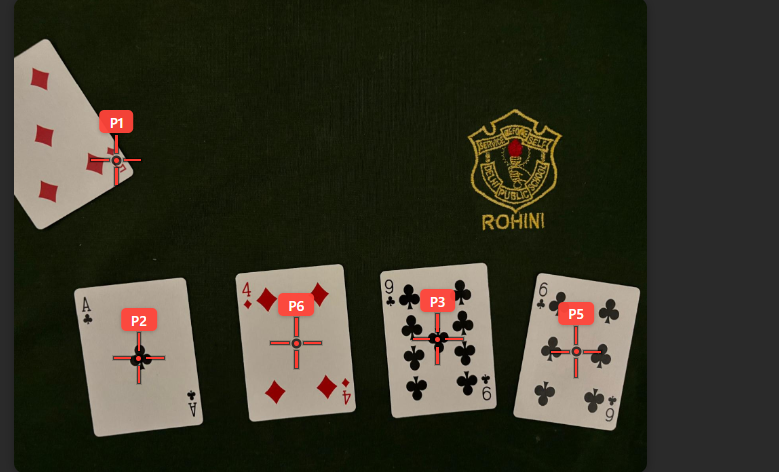

#### Using coordinates to send terminal cmd

In [ ]:
import cv2 
import numpy as np 
import subprocess

marker_length = 0.05
camera_matrix = np.array([[2480.0, 0.0, 600.0],
                          [0.0, 2480.0, 800.0],
                          [0.0, 0.0, 1.0]], dtype=np.float32)
dist_coeffs = np.zeros((4,1), dtype=np.float32)

def get_pixel_to_metric_ratio(corners):
    """Calculates meters represented by one pixel at current value of Z"""

    pixel_perimeter = cv2.arcLength(corners[0], True)
    avg_pixel_side = pixel_perimeter / 4.0

    return marker_length / avg_pixel_side

def transform_to_world_frame(target_px, marker_center_px, m_per_px):
    """Converts pixel value to metric units"""

    dx_px = target_px[0] - marker_center_px[0]
    dy_px = target_px[1] - marker_center_px[1]

    dx_m = dx_px * m_per_px
    dy_m = -(dy_px * m_per_px)

    return dx_m, dy_m

image = cv2.imread(r"/home/kshitij_jha/prap-25-26/vision/marker copy.jpeg")
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)

corners, ids, _ = detector.detectMarkers(image)

if ids is not None: 
    m_per_px = get_pixel_to_metric_ratio(corners)

    marker_center = np.mean(corners[0][0], axis=0)

    yolo_bbox = [300, 1100, 366, 1250] #results[0].boxes.xyxy

    center_u = (yolo_bbox[0] + yolo_bbox[2])/2
    center_v = (yolo_bbox[1] + yolo_bbox[3])/2
    target_pixel = (center_u, center_v) # (333, 1175)

    rel_x, rel_y = transform_to_world_frame(target_pixel, marker_center, m_per_px)

    x_val = round(float(rel_x), 5)
    y_val = round(float(rel_y), 5)

    ros_cmd = (
        f'ros2 action send_goal /move_pose poker_interfaces/action/MovePose '
        f'"{{x: {x_val}, y: {y_val}, z:0.0, pitch: 0.0, roll: 0.0, duration: 5.0}}"'
    )

    print(f"\n--- Coordinate Information ---")
    print(f"Card Center (Pixels): {target_pixel}")
    print(f"Target (m): X={x_val}, Y={y_val}")
    print(f"\nExecuting this command:\n{ros_cmd}")
    
    # subprocess.run(ros_cmd, shell=True)

else:
    print("Marker not detected. Check image path or lighting.")


--- Coordinate Information ---
Card Center (Pixels): (333.0, 1175.0)
Target (m): X=-0.10073, Y=-0.11229

Executing this command:
ros2 action send_goal /move_pose poker_interfaces/action/MovePose "{x: -0.10073, y: -0.11229, z:0.0, pitch: 0.0, roll: 0.0, duration: 5.0}"
